Activity 1:Train sentiment analysis on a larger dataset (e.g., IMDB reviews or Twitter data).


In [1]:
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

# 1. Load IMDB dataset (50,000 reviews: 25k train, 25k test)
vocab_size = 10000  # top 10k words
maxlen = 200        # max review length

(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=vocab_size)

# 2. Pad sequences (so all reviews have same length)
x_train = pad_sequences(x_train, maxlen=maxlen)
x_test = pad_sequences(x_test, maxlen=maxlen)

# 3. Build LSTM model
model = Sequential([
    Embedding(vocab_size, 128, input_length=maxlen),
    LSTM(128, return_sequences=False),
    Dropout(0.5),
    Dense(1, activation="sigmoid")
])

model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

# 4. Train model
history = model.fit(
    x_train, y_train,
    epochs=5,
    batch_size=64,
    validation_data=(x_test, y_test)
)

# 5. Evaluate model
loss, acc = model.evaluate(x_test, y_test)
print(f"Test Accuracy: {acc:.4f}")


17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step - accuracy: 0.6895 - loss: 0.5685 - val_accuracy: 0.8534 - val_loss: 0.3420
Epoch 2/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.8969 - loss: 0.2663 - val_accuracy: 0.8480 - val_loss: 0.3625
Epoch 3/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.9276 - loss: 0.1940 - val_accuracy: 0.8672 - val_loss: 0.3243
Epoch 4/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.9505 - loss: 0.1401 - val_accuracy: 0.8490 - val_loss: 0.3995
Epoch 5/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.9644 - loss: 0.1036 - val_accuracy: 0.8406 - val_loss: 0.4451
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8378 - loss: 0.4586
Test Accuracy: 0.8406


Activity 2:Compare accuracy of different classifiers (Naive Bayes, Logistic Regression, SVM).

In [2]:
# Sentiment Analysis with Multiple Classifiers (IMDB Dataset)
# ----------------------------------------------------------
import numpy as np
from tensorflow.keras.datasets import imdb
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer

# 1. Load IMDB Dataset (raw format)
num_words = 10000
maxlen = 200
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=num_words)

# Decode IMDB dataset to text
word_index = imdb.get_word_index()
index_word = {v+3: k for k, v in word_index.items()}
index_word[0], index_word[1], index_word[2], index_word[3] = "<PAD>", "<START>", "<UNK>", "<UNUSED>"

def decode_review(encoded_review):
    return " ".join([index_word.get(i, "?") for i in encoded_review])

x_train_text = [" ".join([index_word.get(i, "?") for i in seq]) for seq in x_train]
x_test_text = [" ".join([index_word.get(i, "?") for i in seq]) for seq in x_test]

# 2. Convert text to Bag-of-Words with TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer(max_features=10000)

X_train_tfidf = vectorizer.fit_transform(x_train_text)
X_test_tfidf = vectorizer.transform(x_test_text)

# 3. Train and Compare Classifiers

# Naive Bayes
nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train)
nb_pred = nb.predict(X_test_tfidf)
nb_acc = accuracy_score(y_test, nb_pred)

# Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_tfidf, y_train)
lr_pred = lr.predict(X_test_tfidf)
lr_acc = accuracy_score(y_test, lr_pred)

# Support Vector Machine
svm = LinearSVC()
svm.fit(X_train_tfidf, y_train)
svm_pred = svm.predict(X_test_tfidf)
svm_acc = accuracy_score(y_test, svm_pred)

# 4. Print Results
print("Accuracy Comparison:")
print(f"Naive Bayes:        {nb_acc*100:.2f}%")
print(f"Logistic Regression:{lr_acc*100:.2f}%")
print(f"SVM:                {svm_acc*100:.2f}%")


1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Accuracy Comparison:
Naive Bayes:        83.97%
Logistic Regression:88.39%
SVM:                87.40%


Activity 3:Apply Word2Vec embeddings for sentiment classification.

In [3]:
!pip install gensim

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.6/26.6 MB 89.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 113.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.2/38.2 MB 14.6 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.1
    Uninstalling scipy-1.16.1:
      Successfully uninstalled scipy-1.16.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.12.0.88 requi

In [1]:
# Sentiment Analysis using Word2Vec Embeddings
# ---------------------------------------------
import numpy as np
from tensorflow.keras.datasets import imdb
from gensim.models import Word2Vec
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

# 1. Load IMDB Dataset (as raw text)
num_words = 20000
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=num_words)

word_index = imdb.get_word_index()
index_word = {v+3: k for k, v in word_index.items()}
index_word[0], index_word[1], index_word[2], index_word[3] = "<PAD>", "<START>", "<UNK>", "<UNUSED>"

# Convert integer sequences back to text
def decode_review(encoded_review):
    return [index_word.get(i, "?") for i in encoded_review]

train_sentences = [decode_review(seq) for seq in x_train]
test_sentences = [decode_review(seq) for seq in x_test]

# 2. Train Word2Vec model
w2v_model = Word2Vec(
    sentences=train_sentences,
    vector_size=100,   # Embedding size
    window=5,
    min_count=2,
    workers=4
)

# 3. Represent each review as average Word2Vec embedding
def get_avg_w2v(sentence, model, vector_size):
    vectors = [model.wv[word] for word in sentence if word in model.wv]
    return np.mean(vectors, axis=0) if vectors else np.zeros(vector_size)

X_train_w2v = np.array([get_avg_w2v(sent, w2v_model, 100) for sent in train_sentences])
X_test_w2v  = np.array([get_avg_w2v(sent, w2v_model, 100) for sent in test_sentences])

# 4. Train Classifier on Word2Vec features
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train_w2v, y_train)
y_pred = clf.predict(X_test_w2v)

# 5. Evaluate Model
acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy using Word2Vec + Logistic Regression: {acc*100:.2f}%")


Test Accuracy using Word2Vec + Logistic Regression: 83.80%


Activity 4: Visualize word importance using word clouds.


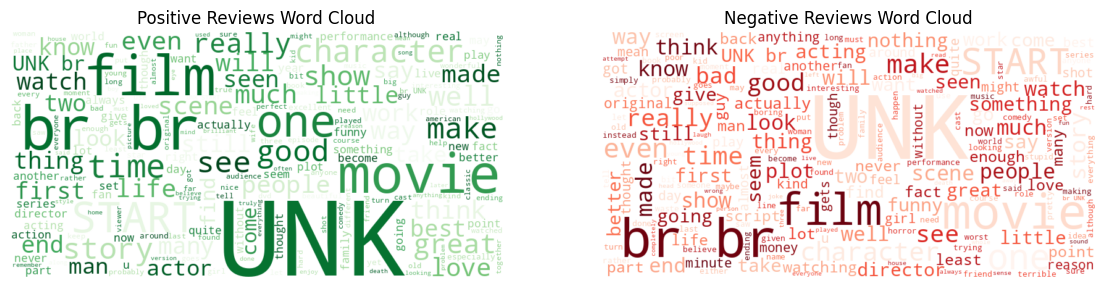

In [2]:
# Word Cloud Visualization for IMDB Reviews
# -----------------------------------------
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from tensorflow.keras.datasets import imdb

# Load IMDB dataset
num_words = 10000
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=num_words)

# Decode IMDB reviews back to text
word_index = imdb.get_word_index()
index_word = {v+3: k for k, v in word_index.items()}
index_word[0], index_word[1], index_word[2], index_word[3] = "<PAD>", "<START>", "<UNK>", "<UNUSED>"

def decode_review(encoded_review):
    return " ".join([index_word.get(i, "?") for i in encoded_review])

# Separate positive and negative reviews
positive_reviews = [decode_review(seq) for seq, label in zip(x_train, y_train) if label == 1]
negative_reviews = [decode_review(seq) for seq, label in zip(x_train, y_train) if label == 0]

# Generate word clouds
positive_text = " ".join(positive_reviews[:2000])  # subset for speed
negative_text = " ".join(negative_reviews[:2000])

positive_wc = WordCloud(width=800, height=400, background_color="white", colormap="Greens").generate(positive_text)
negative_wc = WordCloud(width=800, height=400, background_color="white", colormap="Reds").generate(negative_text)

# Plot Word Clouds
plt.figure(figsize=(14,6))

plt.subplot(1,2,1)
plt.imshow(positive_wc, interpolation="bilinear")
plt.axis("off")
plt.title("Positive Reviews Word Cloud")

plt.subplot(1,2,2)
plt.imshow(negative_wc, interpolation="bilinear")
plt.axis("off")
plt.title("Negative Reviews Word Cloud")

plt.show()


Activity 5:Prepare a confusion matrix for better error analysis

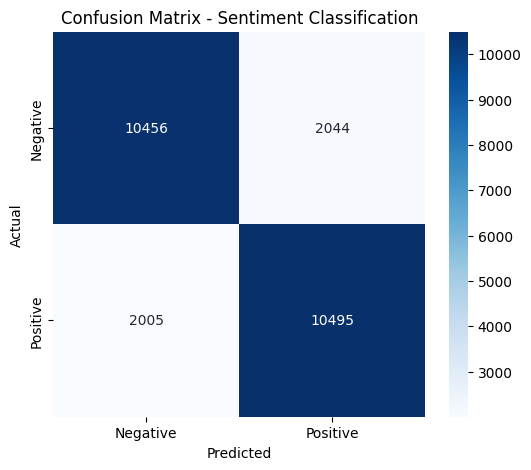


Classification Report:

              precision    recall  f1-score   support

    Negative       0.84      0.84      0.84     12500
    Positive       0.84      0.84      0.84     12500

    accuracy                           0.84     25000
   macro avg       0.84      0.84      0.84     25000
weighted avg       0.84      0.84      0.84     25000



In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Assume you already have true labels (y_test) and predicted labels (y_pred)
# Example: using Logistic Regression with TF-IDF (from previous step)

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues",
            xticklabels=["Negative", "Positive"],
            yticklabels=["Negative", "Positive"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Sentiment Classification")
plt.show()

# Print detailed classification report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=["Negative", "Positive"]))
